In [4]:
import pandas as pd

df = pd.read_csv("test.csv")

# we check for null values
print(df.isnull().sum())

#the null values are filled w 0 
df['Arrival Delay in Minutes'] = df['Arrival Delay in Minutes'].fillna(0)

print()
print("-------------------------------------------------------")
print()

# confirm no more missing
print(df.isnull().sum())


Unnamed: 0                            0
id                                    0
Gender                                0
Customer Type                         0
Age                                   0
Type of Travel                        0
Class                                 0
Flight Distance                       0
Inflight wifi service                 0
Departure/Arrival time convenient     0
Ease of Online booking                0
Gate location                         0
Food and drink                        0
Online boarding                       0
Seat comfort                          0
Inflight entertainment                0
On-board service                      0
Leg room service                      0
Baggage handling                      0
Checkin service                       0
Inflight service                      0
Cleanliness                           0
Departure Delay in Minutes            0
Arrival Delay in Minutes             83
satisfaction                          0


In [5]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

categorical_cols = ["Gender", "Customer Type", "Type of Travel", "Class", "satisfaction"]

for col in categorical_cols:
    df[col] = le.fit_transform(df[col])

df.head(10)


,Unnamed: 0,id,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,...,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,satisfaction
0,0,19556,0,0,52,0,1,160,5,4,...,5,5,5,5,2,5,5,50,44.0,1
1,1,90035,0,0,36,0,0,2863,1,1,...,4,4,4,4,3,4,5,0,0.0,1
2,2,12360,1,1,20,0,1,192,2,0,...,2,4,1,3,2,2,2,0,0.0,0
3,3,77959,1,0,44,0,0,3377,0,0,...,1,1,1,1,3,1,4,0,6.0,1
4,4,36875,0,0,49,0,1,1182,2,3,...,2,2,2,2,4,2,4,0,20.0,1
5,5,39177,1,0,16,0,1,311,3,3,...,5,4,3,1,1,2,5,0,0.0,1
6,6,79433,0,0,77,0,0,3987,5,5,...,5,5,5,5,4,5,3,0,0.0,1
7,7,97286,0,0,43,0,0,2556,2,2,...,4,4,4,4,5,4,3,77,65.0,1
8,8,27508,1,0,47,0,1,556,5,2,...,5,2,2,5,3,3,5,1,0.0,1
9,9,62482,0,0,46,0,0,1744,2,2,...,4,4,4,4,5,4,4,28,14.0,1


In [ ]:
df_original = pd.read_csv("test.csv") #here we can just compare the above encoded values with the original values in the dataset
df_original.head(10)

,Unnamed: 0,id,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,...,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,satisfaction
0,0,19556,Female,Loyal Customer,52,Business travel,Eco,160,5,4,...,5,5,5,5,2,5,5,50,44.0,satisfied
1,1,90035,Female,Loyal Customer,36,Business travel,Business,2863,1,1,...,4,4,4,4,3,4,5,0,0.0,satisfied
2,2,12360,Male,disloyal Customer,20,Business travel,Eco,192,2,0,...,2,4,1,3,2,2,2,0,0.0,neutral or dissatisfied
3,3,77959,Male,Loyal Customer,44,Business travel,Business,3377,0,0,...,1,1,1,1,3,1,4,0,6.0,satisfied
4,4,36875,Female,Loyal Customer,49,Business travel,Eco,1182,2,3,...,2,2,2,2,4,2,4,0,20.0,satisfied
5,5,39177,Male,Loyal Customer,16,Business travel,Eco,311,3,3,...,5,4,3,1,1,2,5,0,0.0,satisfied
6,6,79433,Female,Loyal Customer,77,Business travel,Business,3987,5,5,...,5,5,5,5,4,5,3,0,0.0,satisfied
7,7,97286,Female,Loyal Customer,43,Business travel,Business,2556,2,2,...,4,4,4,4,5,4,3,77,65.0,satisfied
8,8,27508,Male,Loyal Customer,47,Business travel,Eco,556,5,2,...,5,2,2,5,3,3,5,1,0.0,satisfied
9,9,62482,Female,Loyal Customer,46,Business travel,Business,1744,2,2,...,4,4,4,4,5,4,4,28,14.0,satisfied


In [ ]:
from sklearn.preprocessing import MinMaxScaler

numerical_cols = ["Age", "Flight Distance", "Inflight wifi service", "Departure/Arrival time convenient",
                  "Ease of Online booking", "Gate location", "Food and drink", "Online boarding",
                  "Seat comfort", "Inflight entertainment", "On-board service", "Leg room service",
                  "Baggage handling", "Checkin service", "Inflight service", "Cleanliness",
                  "Departure Delay in Minutes", "Arrival Delay in Minutes"]

scaler = MinMaxScaler()

df[numerical_cols] = scaler.fit_transform(df[numerical_cols])

In [ ]:
X = df.drop(columns=["satisfaction"])
y = df["satisfaction"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (25976, 24)
y shape: (25976,)


[[1801 1144]
 [1314  937]]
              precision    recall  f1-score   support

           0       0.58      0.61      0.59      2945
           1       0.45      0.42      0.43      2251

    accuracy                           0.53      5196
   macro avg       0.51      0.51      0.51      5196
weighted avg       0.52      0.53      0.52      5196



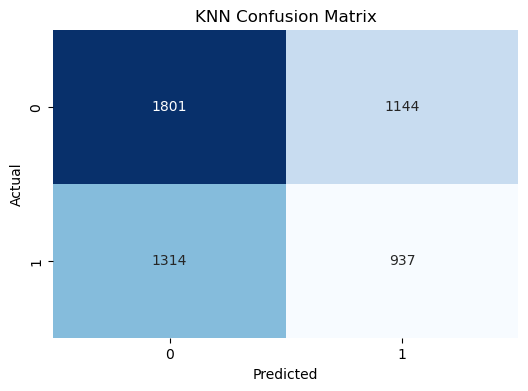

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# below, we perform an 80/20 split for the train/test sets respectively
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# we train the KNN model using k=5
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)

# we evaluate KNN now
y_pred_knn = knn.predict(X_test)
print(confusion_matrix(y_test, y_pred_knn))
print(classification_report(y_test, y_pred_knn))

# we visualize the confusion matrix for better understanding
cm = confusion_matrix(y_test, y_pred_knn)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title('KNN Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()


[[2767  178]
 [ 172 2079]]
              precision    recall  f1-score   support

           0       0.94      0.94      0.94      2945
           1       0.92      0.92      0.92      2251

    accuracy                           0.93      5196
   macro avg       0.93      0.93      0.93      5196
weighted avg       0.93      0.93      0.93      5196



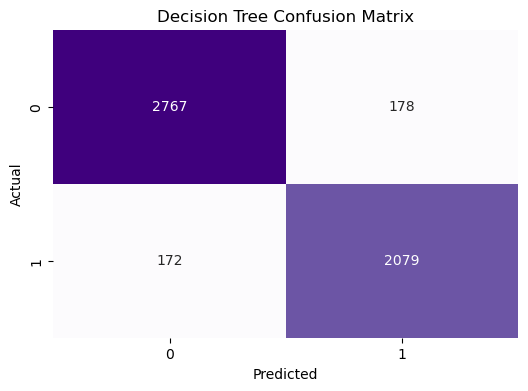

In [ ]:
from sklearn.tree import DecisionTreeClassifier

# we train the Decision Tree model
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)

# we evaluate decision tree now
y_pred_dt = dt.predict(X_test)
print(confusion_matrix(y_test, y_pred_dt))
print(classification_report(y_test, y_pred_dt))

# we visualize the confusion matrix for decision tree
cm_dt = confusion_matrix(y_test, y_pred_dt)
plt.figure(figsize=(6,4))
sns.heatmap(cm_dt, annot=True, fmt='d', cmap='Purples', cbar=False)
plt.title('Decision Tree Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()
